In [1]:
import os
import pickle
import random
import numpy as np
import scipy.signal
import scipy.fft
import scipy.fftpack
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from config import DUTCH_30_PATH
from run_pipeline import load_mfa_alignments

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {DEVICE}")

SEED = 37
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch
  Using device: cuda


In [8]:
# ── 1. TORCH FIRST (before anything touches CUDA) ────────────────────────────
import torch
import torchaudio

# ── 2. TRANSFORMERS SECOND (before librosa loads via project imports) ─────────
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

# ── 3. STANDARD LIBRARIES ───────────────────────────────────────────────────────
import os
import gc
import copy
import glob
import json
import pickle
import tempfile
from datetime import datetime
from collections import Counter, defaultdict
from itertools import combinations

# ── 4. THIRD-PARTY (no CUDA) ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

# ── 5. PROJECT IMPORTS ────────────────────────────────────────────────────────
from extract_features import extractHG, stackFeatures, downsampleLabels, extractMelSpecs
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from markov_phoneme_model import MarkovPhonemeModel
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic
from dataset_config import Dutch30Config
from experiment_logger import ExperimentLogger

# ── 6. WHISPERX  ──────────────────────────────────────────────────────────
import whisperx

In [2]:

ALL_PIDS = [f'P{i:02d}' for i in range(21, 31)]   # P21–P30
SENTENCE_TEST_FRACTION = 0.2
SENTENCE_SPLIT_SEED    = 37

# Frame settings — align iEEG and MFCC at the SAME 200 fps grid
FRAME_HZ       = 200
FRAMESHIFT_MS  = 5                 # 1000/FRAME_HZ
SR_EEG         = 1024              # iEEG sample rate
WINDOW_MS_EEG  = 15

# Audio MFCC settings
SR_AUDIO_TARGET = 16000            # downsample audio to this if needed
N_MFCC          = 13               # MFCC coefficients
N_MELS          = 40               # mel filterbank channels
MFCC_WIN_MS     = 25               # MFCC analysis window
N_FFT           = 512              # FFT size for MFCC

# Boundary-label settings
LABEL_SIGMA_MS = 8
LABEL_HARD_MS  = 20

# Training
HIDDEN_DIM     = 192
N_LSTM_LAYERS  = 2
DROPOUT        = 0.2
N_EPOCHS       = 40
BATCH_SIZE     = 4
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
POS_WEIGHT     = 20.0

# Modality-dropout fractions during training
MOD_DROPOUT = {'ieeg_only': 0.4, 'audio_only': 0.4, 'both': 0.2}

# Inference + F1
PEAK_HEIGHT     = 0.15
PEAK_DISTANCE   = 8
F1_TOLERANCE_MS = 20

In [3]:
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)


def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)


def build_mel_filterbank(n_mels, n_fft, sr, fmin=0.0, fmax=None):
    """Triangular mel filterbank, (n_mels, n_fft//2 + 1)."""
    if fmax is None:
        fmax = sr / 2.0

    mel_pts = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_pts  = mel_to_hz(mel_pts)
    # Bin centers in FFT-bin space
    bin_pts = np.floor((n_fft + 1) * hz_pts / sr).astype(int)
    bin_pts = np.clip(bin_pts, 0, n_fft // 2)

    n_bins = n_fft // 2 + 1
    fb = np.zeros((n_mels, n_bins), dtype=np.float32)
    for m in range(n_mels):
        left, center, right = bin_pts[m], bin_pts[m + 1], bin_pts[m + 2]
        if center > left:
            for k in range(left, center):
                fb[m, k] = (k - left) / (center - left)
        if right > center:
            for k in range(center, right):
                fb[m, k] = (right - k) / (right - center)
    return fb


def compute_mfcc(audio, sr,
                 n_mfcc=N_MFCC, n_mels=N_MELS,
                 frame_hz=FRAME_HZ, win_ms=MFCC_WIN_MS, n_fft=N_FFT,
                 pre_emphasis=0.97):
    """MFCCs at frame_hz fps, no librosa.

    Steps: pre-emphasis → framing → Hamming window → FFT → power
           → mel filterbank → log → DCT-II → take first n_mfcc.
    """
    audio = np.asarray(audio, dtype=np.float32)
    # Normalize amplitude (audio may be int16-style with large values)
    if np.abs(audio).max() > 5.0:
        audio = audio / np.abs(audio).max()

    # 1. Pre-emphasis
    audio = scipy.signal.lfilter([1.0, -pre_emphasis], [1.0], audio)

    # 2. Framing
    win_samples = int(round(win_ms * sr / 1000.0))
    hop_samples = int(round(sr / frame_hz))
    n_frames = (len(audio) - win_samples) // hop_samples + 1
    if n_frames <= 0:
        return np.zeros((0, n_mfcc), dtype=np.float32)

    window = np.hamming(win_samples).astype(np.float32)
    frames = np.zeros((n_frames, win_samples), dtype=np.float32)
    for i in range(n_frames):
        s = i * hop_samples
        frames[i] = audio[s:s + win_samples] * window

    # 3. Power spectrum (magnitude squared)
    spec = np.abs(scipy.fft.rfft(frames, n_fft, axis=1)) ** 2

    # 4. Mel filterbank
    mel_fb = build_mel_filterbank(n_mels, n_fft, sr)
    mel_energies = spec @ mel_fb.T            # (n_frames, n_mels)

    # 5. Log
    log_mel = np.log(np.maximum(mel_energies, 1e-10))

    # 6. DCT-II → MFCC
    mfcc = scipy.fftpack.dct(log_mel, type=2, axis=1, norm='ortho')[:, :n_mfcc]
    return mfcc.astype(np.float32)


def add_delta_features(mfcc, delta_window=2):
    """Add first + second derivatives, returns (n_frames, 3*n_mfcc)."""
    n_frames, n = mfcc.shape

    def _delta(x):
        d = np.zeros_like(x)
        for t in range(n_frames):
            num = np.zeros(n, dtype=np.float32)
            denom = 0.0
            for k in range(1, delta_window + 1):
                tb = max(0, t - k)
                tf = min(n_frames - 1, t + k)
                num += k * (x[tf] - x[tb])
                denom += 2.0 * k * k
            d[t] = num / denom if denom > 0 else 0.0
        return d

    delta = _delta(mfcc)
    delta_delta = _delta(delta)
    return np.concatenate([mfcc, delta, delta_delta], axis=1)

In [4]:

def extract_eeg_frames(eeg, sr=SR_EEG, window_ms=WINDOW_MS_EEG,
                       frameshift_ms=FRAMESHIFT_MS, smoothing_hz=10.0):
    """Per-frame high-gamma envelope (matches production extractHG)."""
    win = window_ms / 1000.0
    shift = frameshift_ms / 1000.0
    data = scipy.signal.detrend(eeg, axis=0)

    sos_hg = scipy.signal.iirfilter(4, [70/(sr/2), 170/(sr/2)],
                                    btype='bandpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos_hg, data, axis=0)
    for f_notch in (100.0, 150.0):
        sos_n = scipy.signal.iirfilter(4, [(f_notch-2)/(sr/2), (f_notch+2)/(sr/2)],
                                       btype='bandstop', output='sos')
        data = scipy.signal.sosfiltfilt(sos_n, data, axis=0)
    pwr = data ** 2
    sos_lp = scipy.signal.iirfilter(4, smoothing_hz/(sr/2),
                                    btype='lowpass', output='sos')
    smoothed = np.abs(scipy.signal.sosfiltfilt(sos_lp, pwr, axis=0))

    n_win = int(np.floor((data.shape[0] - win*sr) / (shift*sr)))
    feat = np.zeros((n_win, data.shape[1]), dtype=np.float32)
    for w in range(n_win):
        s = int(np.floor(w * shift * sr))
        e = int(np.floor(s + win * sr))
        feat[w, :] = smoothed[s:e, :].mean(axis=0)
    return np.sqrt(feat).astype(np.float32)

In [5]:
def boundary_labels_from_mfa(phone_alignments, n_frames,
                              frame_hz=FRAME_HZ,
                              sigma_ms=LABEL_SIGMA_MS):
    """Soft Gaussian labels on the n_frames grid."""
    sigma_frames = sigma_ms * frame_hz / 1000.0
    half_window = max(1, int(np.ceil(3 * sigma_frames)))
    labels = np.zeros(n_frames, dtype=np.float32)

    boundary_times = sorted(set(
        round(t * frame_hz) / frame_hz
        for ph in phone_alignments
        for t in (ph['start_s'], ph['end_s'])
    ))

    for t in boundary_times:
        c = int(round(t * frame_hz))
        for off in range(-half_window, half_window + 1):
            f = c + off
            if 0 <= f < n_frames:
                w = float(np.exp(-(off ** 2) / (2 * sigma_frames ** 2)))
                if w > labels[f]:
                    labels[f] = w
    return labels, boundary_times

In [9]:
# create the pipeline
from run_pipeline import (
    # ── Configuration ─────────────────────────────────────────────────────
    DEFAULT_RUN_CONFIG,          # dict with all default hyperparameters

    # ── Pipeline paths (choose one) ───────────────────────────────────────
    # run_path_a,                # Path A: wav2vec/WhisperX boundary detection
    #                            #   - detects phoneme boundaries from audio in real time
    #                            #   - uses step4_custom_detector + step5_accumulate
    #                            #   - requires WhisperX model loaded (slow, ~1GB RAM)
    #                            #   - 3-level checkpoint system (step5 → frame → step3)
    run_path_b,                  # Path B: MFA pre-aligned TextGrids
                                 #   - reads phoneme timestamps from MFA TextGrid files
                                 #   - bypasses step4 + step5_accumulate entirely
                                 #   - requires mfa_output/ TextGrids to exist already
                                 #   - only needs step3 checkpoint (for train/test split)

    # ── Classification ────────────────────────────────────────────────────
    run_from_config,             # train + evaluate per-patient classifiers (uses run_config)
    # run_experiment,            # same but with explicit keyword args instead of dict

    # ── Analysis & diagnostics ────────────────────────────────────────────
    count,                       # print train/test sample counts
    analyze_consecutive_predictions,  # per-patient consecutive-correct runs + position stats
    # diagnose_mfa_loss,         # show where MFA phonemes are lost (min_samples, missing TG)
    # mfa_coverage_summary,      # per-patient MFA alignment coverage (sentences, phones)

    # ── MFA setup (one-time, already done for P21-P30) ────────────────────
    # export_sentences_for_mfa,  # export .wav + .lab per sentence for MFA input
    # clean_text_for_mfa,        # strip punctuation from transcripts
    # load_mfa_alignments,       # read TextGrid files into dict

    # ── Sweep ─────────────────────────────────────────────────────────────
    run_sweep,                 # grid search over stacking_order, step_size, frames, etc.

    # ── Helpers ───────────────────────────────────────────────────────────
    # attach_whisperx,           # load WhisperX model (only needed for Path A)
    # make_checkpoint_names,     # generate pickle filenames from run_config
)

run_config = dict(DEFAULT_RUN_CONFIG)
# Override if needed:
run_config['use_viterbi'] = True
# run_config['patient_range'] = (21, 30)
# run_config['stacking_order'] = 7
# run_config['stacking_step_size'] = 1
run_config['stacking_order']     = 20    # ±100 ms context at 5 ms shift
run_config['stacking_step_size'] = 1

# ---- Pipeline setup ----
extractor = Dutch30FeatureExtractor()
pipeline = Dutch30Pipeline(
    dutch30_extractor=extractor,
    debug_mode=False,
    feature_extraction_method=run_config['feature_extraction_method'],
    use_wav2vec=False,
    subtract_baseline=run_config['subtract_baseline'],
    use_rms_boundaries=False,
    use_multifeature=False,
)
pipeline.enable_debug()

# ── Run Path B (MFA) ─────────────────────────────────────────────────────────
cached_train, cached_test = run_path_b(pipeline, run_config)

# ── Classification ────────────────────────────────────────────────────────────
# name, params, results = run_from_config(pipeline, run_config)

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, groups=False

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 (FIXED) — Joint dataset builder using raw EEG + sentence_list timing
# ═══════════════════════════════════════════════════════════════════════════════
# `eeg_segments` in pipeline.split_result is per-WORD (~45ms each), NOT
# per-sentence. The sentence-level timing is in sentence_list[i]['stim_start_idx']
# and ['stim_end_idx'] (sample indices into the raw 1024 Hz EEG/stimuli arrays).
# We slice raw EEG and audio directly using these indices.

import os
from math import gcd
from config import DUTCH_30_PATH


def get_audio_sr_real(pipeline):
    """Get actual audio sample rate. Default 48000."""
    try:
        return int(pipeline.config.audio_sr)
    except (AttributeError, TypeError):
        return 48000


def get_channel_keep_indices(pipeline, pid):
    """Channel indices kept after exclusion (None if no exclusion applied)."""
    if not hasattr(pipeline, 'channel_masks'):
        return None
    cm = pipeline.channel_masks.get(pid)
    if cm is None:
        return None
    if isinstance(cm, dict) and 'keep_indices' in cm:
        return np.asarray(cm['keep_indices'])
    if isinstance(cm, np.ndarray) and cm.dtype == bool:
        return np.where(cm)[0]
    return None


def build_joint_dataset(pipeline, patient_ids):
    """Per-sentence dataset built from RAW EEG/audio + sentence_list timing.

    For each sentence in each patient:
      1. Get (stim_start_idx, stim_end_idx) from sentence_list
      2. Slice raw EEG and audio using these indices (audio at audio_sr)
      3. Apply channel exclusion (if any)
      4. Run extract_eeg_frames + compute_mfcc + boundary_labels_from_mfa
    """
    dataset = []
    audio_sr_raw = get_audio_sr_real(pipeline)
    print(f"  Audio raw sample rate: {audio_sr_raw} Hz  →  resample to {SR_AUDIO_TARGET} Hz")

    for pid in patient_ids:
        raw_eeg_path   = os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy')
        raw_audio_path = os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_audio.npy')
        if not (os.path.exists(raw_eeg_path) and os.path.exists(raw_audio_path)):
            print(f"  {pid}: raw files missing, skipping")
            continue

        raw_eeg   = np.load(raw_eeg_path)
        raw_audio = np.load(raw_audio_path)

        wd = pipeline.split_result.get('word_segments_dict', {}).get(pid, {})
        sentence_list = wd.get('sentence_list', [])
        if not sentence_list:
            print(f"  {pid}: no sentence_list, skipping")
            continue

        mfa = load_mfa_alignments(pid)
        if not mfa:
            print(f"  {pid}: no MFA alignments, skipping")
            continue

        # Apply channel exclusion to raw EEG
        keep_idx = get_channel_keep_indices(pipeline, pid)
        if keep_idx is not None:
            raw_eeg = raw_eeg[:, keep_idx]

        n_used = 0
        for sent_idx, sent_info in enumerate(sentence_list):
            if sent_idx not in mfa:
                continue
            phone_alignments = mfa[sent_idx]
            if not phone_alignments:
                continue

            # Sentence start/end in EEG sample units (1024 Hz)
            try:
                eeg_start = int(sent_info['stim_start_idx'])
                eeg_end   = int(sent_info['stim_end_idx'])
            except (KeyError, TypeError):
                continue

            if eeg_end <= eeg_start:
                continue
            sent_dur_s = (eeg_end - eeg_start) / SR_EEG
            if sent_dur_s < 0.5:                     # filter degenerate sentences
                continue

            # Audio is at audio_sr_raw, EEG at SR_EEG → convert indices
            audio_start = int(round(eeg_start * audio_sr_raw / SR_EEG))
            audio_end   = int(round(eeg_end   * audio_sr_raw / SR_EEG))

            sent_eeg   = raw_eeg  [eeg_start  :eeg_end]
            sent_audio = raw_audio[audio_start:audio_end]
            if sent_eeg.shape[0] < 50 or sent_audio.shape[0] < 500:
                continue

            try:
                # ── iEEG frames (200 fps high-gamma envelope) ──────────────
                eeg_frames = extract_eeg_frames(sent_eeg)
                n_frames   = eeg_frames.shape[0]
                if n_frames < 10:
                    continue

                # ── Audio resample 48000 → 16000 (no librosa) ───────────────
                if audio_sr_raw != SR_AUDIO_TARGET:
                    g = gcd(int(audio_sr_raw), int(SR_AUDIO_TARGET))
                    up   = int(SR_AUDIO_TARGET / g)
                    down = int(audio_sr_raw   / g)
                    sent_audio_rs = scipy.signal.resample_poly(sent_audio, up, down)
                else:
                    sent_audio_rs = sent_audio

                # ── MFCC at 200 fps + delta + delta-delta ───────────────────
                mfcc = compute_mfcc(sent_audio_rs, sr=SR_AUDIO_TARGET)
                mfcc = add_delta_features(mfcc)

                # ── Pad/truncate MFCC to match EEG frame count ──────────────
                if mfcc.shape[0] < n_frames:
                    pad = np.zeros((n_frames - mfcc.shape[0], mfcc.shape[1]),
                                    dtype=np.float32)
                    mfcc = np.concatenate([mfcc, pad], axis=0)
                elif mfcc.shape[0] > n_frames:
                    mfcc = mfcc[:n_frames]

                # ── Soft Gaussian boundary labels ──────────────────────────
                labels, boundary_times = boundary_labels_from_mfa(
                    phone_alignments, n_frames)

            except Exception as e:
                print(f"    {pid} sent {sent_idx}: feature extraction failed: {e}")
                continue

            dataset.append({
                'pid':                 pid,
                'sentence_idx':        sent_idx,
                'eeg':                 eeg_frames,
                'mfcc':                mfcc,
                'labels':              labels,
                'boundary_times':      boundary_times,
                'n_phonemes':          len(phone_alignments),
                'sentence_duration_s': sent_dur_s,
            })
            n_used += 1

        print(f"  {pid}: {n_used} sentences extracted "
              f"(of {len(sentence_list)} in sentence_list)")

    return dataset


# Build dataset
if 'pipeline' in dir():
    print("\n  Building joint dataset from raw EEG/audio + sentence_list timing...")
    full_ds = build_joint_dataset(pipeline, ALL_PIDS)
    train_ds, test_ds = split_by_sentence(full_ds)
    print(f"\n  total: {len(full_ds)} sentences from "
          f"{len(set(d['pid'] for d in full_ds))} patients")
    print(f"  train: {len(train_ds)} sentences  test: {len(test_ds)} sentences")
    if full_ds:
        d0 = full_ds[0]
        print(f"\n  Example shapes ({d0['pid']} sent {d0['sentence_idx']}):")
        print(f"    eeg:    {d0['eeg'].shape}      ({d0['eeg'].shape[0]/FRAME_HZ:.2f}s)")
        print(f"    mfcc:   {d0['mfcc'].shape}     ({d0['mfcc'].shape[0]/FRAME_HZ:.2f}s)")
        print(f"    labels: {d0['labels'].shape}   ({(d0['labels']>0.5).sum()} positives)")
        print(f"    duration_s: {d0['sentence_duration_s']:.2f}")
        print(f"    boundary_times: {len(d0['boundary_times'])} "
              f"in [{min(d0['boundary_times']):.2f}, {max(d0['boundary_times']):.2f}]s")


  Building joint dataset from raw EEG/audio + sentence_list timing...
  Audio raw sample rate: 48000 Hz  →  resample to 16000 Hz
  P21: 90 sentences extracted (of 200 in sentence_list)
  P22: 97 sentences extracted (of 200 in sentence_list)
  P23: 98 sentences extracted (of 201 in sentence_list)
  P24: 89 sentences extracted (of 200 in sentence_list)
  P25: 99 sentences extracted (of 201 in sentence_list)
  P26: 80 sentences extracted (of 201 in sentence_list)
  P27: 100 sentences extracted (of 201 in sentence_list)
  P28: 100 sentences extracted (of 200 in sentence_list)
  P29: 100 sentences extracted (of 201 in sentence_list)
  P30: 100 sentences extracted (of 200 in sentence_list)

  total: 953 sentences from 10 patients
  train: 762 sentences  test: 191 sentences

  Example shapes (P21 sent 0):
    eeg:    (796, 107)      (3.98s)
    mfcc:   (796, 39)     (3.98s)
    labels: (796,)   (78 positives)
    duration_s: 4.00
    boundary_times: 26 in [1.21, 3.94]s


In [11]:
def fit_train_stats(dataset, key):
    by_pid = defaultdict(list)
    for d in dataset:
        by_pid[d['pid']].append(d[key])
    stats = {}
    for pid, arrs in by_pid.items():
        cat = np.concatenate(arrs, axis=0)
        stats[pid] = (cat.mean(axis=0, keepdims=True),
                       cat.std(axis=0, keepdims=True) + 1e-9)
    return stats


def apply_stats(dataset, stats_eeg, stats_mfcc):
    for d in dataset:
        mu, sd = stats_eeg[d['pid']]
        d['eeg'] = ((d['eeg'] - mu) / sd).astype(np.float32)
        if d['pid'] in stats_mfcc:
            mu_m, sd_m = stats_mfcc[d['pid']]
            d['mfcc'] = ((d['mfcc'] - mu_m) / sd_m).astype(np.float32)
    return dataset


if 'train_ds' in dir() and train_ds:
    print("\n  Z-scoring features (per-patient, train statistics)...")
    eeg_stats  = fit_train_stats(train_ds, 'eeg')
    mfcc_stats = fit_train_stats(train_ds, 'mfcc')
    train_ds = apply_stats(train_ds, eeg_stats, mfcc_stats)
    test_ds  = apply_stats(test_ds,  eeg_stats, mfcc_stats)


  Z-scoring features (per-patient, train statistics)...


In [12]:
# Per-patient input projections for iEEG (variable channels). One shared
# projection for MFCC (always 39-dim). Both project to the same hidden dim,
# averaged when both available.

class JointBoundaryDetector(nn.Module):
    def __init__(self, per_patient_eeg_n_ch, mfcc_dim,
                 hidden_dim=HIDDEN_DIM, n_layers=N_LSTM_LAYERS,
                 dropout=DROPOUT, proj_dim=64):
        super().__init__()
        # Per-patient iEEG input projections
        self.eeg_proj = nn.ModuleDict({
            pid: nn.Linear(n_ch, proj_dim)
            for pid, n_ch in per_patient_eeg_n_ch.items()
        })
        # Single shared MFCC projection
        self.mfcc_proj = nn.Linear(mfcc_dim, proj_dim)

        # Shared encoder
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, eeg=None, mfcc=None, pid=None):
        """eeg: (B, T, n_ch_pid) or None
           mfcc: (B, T, mfcc_dim) or None
           pid: str (only batches from one patient at a time)
        """
        h_eeg = self.eeg_proj[pid](eeg) if eeg is not None else None
        h_mfcc = self.mfcc_proj(mfcc) if mfcc is not None else None
        if h_eeg is not None and h_mfcc is not None:
            h = (h_eeg + h_mfcc) / 2.0
        elif h_eeg is not None:
            h = h_eeg
        else:
            h = h_mfcc
        h, _ = self.lstm(h)
        return self.head(h).squeeze(-1)   # (B, T)


In [20]:
# Training loop with modality dropout

def collate_padded_joint(batch):
    """Pad eeg, mfcc, labels to the longest in batch (single-patient batches)."""
    max_len = max(item['eeg'].shape[0] for item in batch)
    n_ch = batch[0]['eeg'].shape[1]
    n_mfcc = batch[0]['mfcc'].shape[1]

    X_eeg  = torch.zeros(len(batch), max_len, n_ch)
    X_mfcc = torch.zeros(len(batch), max_len, n_mfcc)
    Y      = torch.zeros(len(batch), max_len)
    mask   = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        n = item['eeg'].shape[0]
        X_eeg[i, :n]  = torch.from_numpy(item['eeg'])
        X_mfcc[i, :n] = torch.from_numpy(item['mfcc'])
        Y[i, :n]      = torch.from_numpy(item['labels'])
        mask[i, :n]   = True
    return X_eeg, X_mfcc, Y, mask


def sample_modality(rng=random):
    """Choose which modality (or both) to use this batch."""
    r = rng.random()
    cum = 0.0
    for k, p in MOD_DROPOUT.items():
        cum += p
        if r < cum:
            return k
    return 'both'


def train_joint(train_dataset, n_epochs=N_EPOCHS, lr=LR):
    per_patient_eeg_n_ch = {d['pid']: d['eeg'].shape[1] for d in train_dataset}
    mfcc_dim = train_dataset[0]['mfcc'].shape[1]

    model = JointBoundaryDetector(
        per_patient_eeg_n_ch, mfcc_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                   weight_decay=WEIGHT_DECAY)
    pos_weight = torch.tensor([POS_WEIGHT], device=DEVICE)

    by_pid = defaultdict(list)
    for d in train_dataset:
        by_pid[d['pid']].append(d)
    pids = list(by_pid.keys())

    print(f"\n  Training joint detector — {n_epochs} epochs "
          f"(modality dropout: {MOD_DROPOUT})")

    for epoch in range(n_epochs):
        model.train()
        random.shuffle(pids)
        total_loss = 0.0
        total_frames = 0
        modality_counts = defaultdict(int)

        for pid in pids:
            items = by_pid[pid]
            random.shuffle(items)
            for i in range(0, len(items), BATCH_SIZE):
                batch = items[i:i + BATCH_SIZE]
                X_eeg, X_mfcc, Y, mask = collate_padded_joint(batch)
                X_eeg, X_mfcc = X_eeg.to(DEVICE), X_mfcc.to(DEVICE)
                Y, mask = Y.to(DEVICE), mask.to(DEVICE)

                modality = sample_modality()
                modality_counts[modality] += 1

                optimizer.zero_grad()
                if modality == 'ieeg_only':
                    logits = model(eeg=X_eeg, mfcc=None,    pid=pid)
                elif modality == 'audio_only':
                    logits = model(eeg=None,  mfcc=X_mfcc,  pid=pid)
                else:  # 'both'
                    logits = model(eeg=X_eeg, mfcc=X_mfcc,  pid=pid)

                loss = F.binary_cross_entropy_with_logits(
                    logits, Y, pos_weight=pos_weight, reduction='none')
                loss = (loss * mask.float()).sum() / mask.float().sum().clamp(min=1)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item() * mask.float().sum().item()
                total_frames += mask.float().sum().item()

        if (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
            print(f"    epoch {epoch+1:2d}/{n_epochs}  "
                  f"avg_loss={total_loss/max(total_frames,1):.4f}  "
                  f"batches by modality: {dict(modality_counts)}")
    return model


if 'train_ds' in dir() and train_ds:
    model = train_joint(train_ds)



  Training joint detector — 40 epochs (modality dropout: {'ieeg_only': 0.4, 'audio_only': 0.4, 'both': 0.2})
    epoch  5/40  avg_loss=1.5244  batches by modality: {'ieeg_only': 77, 'audio_only': 83, 'both': 32}
    epoch 10/40  avg_loss=1.4935  batches by modality: {'ieeg_only': 84, 'audio_only': 72, 'both': 36}
    epoch 15/40  avg_loss=1.4827  batches by modality: {'ieeg_only': 79, 'audio_only': 83, 'both': 30}
    epoch 20/40  avg_loss=1.4204  batches by modality: {'audio_only': 93, 'ieeg_only': 76, 'both': 23}
    epoch 25/40  avg_loss=1.3524  batches by modality: {'audio_only': 93, 'both': 38, 'ieeg_only': 61}
    epoch 30/40  avg_loss=1.3747  batches by modality: {'both': 52, 'ieeg_only': 72, 'audio_only': 68}
    epoch 35/40  avg_loss=1.3357  batches by modality: {'ieeg_only': 78, 'audio_only': 75, 'both': 39}
    epoch 40/40  avg_loss=1.2914  batches by modality: {'both': 48, 'audio_only': 74, 'ieeg_only': 70}


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Inference (iEEG-only — the deployment mode)
# ═══════════════════════════════════════════════════════════════════════════════

def predict_boundaries_ieeg_only(model, eeg_frames, pid,
                                  peak_height=PEAK_HEIGHT,
                                  peak_distance=PEAK_DISTANCE):
    """Inference using ONLY iEEG (audio not needed)."""
    model.eval()
    with torch.no_grad():
        X = torch.from_numpy(eeg_frames.astype(np.float32)
                              ).unsqueeze(0).to(DEVICE)
        logits = model(eeg=X, mfcc=None, pid=pid)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
    peaks, _ = scipy.signal.find_peaks(
        probs, height=peak_height, distance=peak_distance)
    return peaks, probs


def predict_boundaries_audio_only(model, mfcc_frames, pid,
                                   peak_height=PEAK_HEIGHT,
                                   peak_distance=PEAK_DISTANCE):
    """For comparison: same model using ONLY audio MFCCs."""
    model.eval()
    with torch.no_grad():
        X = torch.from_numpy(mfcc_frames.astype(np.float32)
                              ).unsqueeze(0).to(DEVICE)
        logits = model(eeg=None, mfcc=X, pid=pid)
        probs = torch.sigmoid(logits)[0].cpu().numpy()
    peaks, _ = scipy.signal.find_peaks(
        probs, height=peak_height, distance=peak_distance)
    return peaks, probs

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — F1 evaluation: iEEG-only and audio-only on the same model
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate_f1_modality(model, test_dataset, modality,
                          tolerance_ms=F1_TOLERANCE_MS):
    """modality: 'ieeg' or 'audio' — picks which inference path to use."""
    tol_frames = int(tolerance_ms * FRAME_HZ / 1000)
    per_patient = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for d in test_dataset:
        if modality == 'ieeg':
            peaks, _ = predict_boundaries_ieeg_only(
                model, d['eeg'], d['pid'])
        elif modality == 'audio':
            peaks, _ = predict_boundaries_audio_only(
                model, d['mfcc'], d['pid'])
        else:
            raise ValueError(modality)

        true_frames = sorted(set(int(round(t * FRAME_HZ))
                                  for t in d['boundary_times']))
        used_pred = [False] * len(peaks)
        used_true = [False] * len(true_frames)
        for ti, t in enumerate(true_frames):
            best_pi, best_dist = -1, tol_frames + 1
            for pi, p in enumerate(peaks):
                if used_pred[pi]:
                    continue
                dist = abs(p - t)
                if dist <= tol_frames and dist < best_dist:
                    best_pi, best_dist = pi, dist
            if best_pi >= 0:
                used_pred[best_pi] = True
                used_true[ti] = True
        per_patient[d['pid']]['tp'] += sum(used_pred)
        per_patient[d['pid']]['fp'] += len(peaks) - sum(used_pred)
        per_patient[d['pid']]['fn'] += len(true_frames) - sum(used_true)

    return per_patient


def f1_table(per_patient, label):
    print(f"\n  {label} (tolerance ±{F1_TOLERANCE_MS} ms):")
    print(f"  {'pid':<5} {'TP':>6} {'FP':>6} {'FN':>6} "
          f"{'precision':>10} {'recall':>9} {'F1':>7}")
    print("  " + "-" * 55)
    f1s = []
    for pid in sorted(per_patient):
        s = per_patient[pid]
        prec = s['tp'] / max(s['tp'] + s['fp'], 1)
        rec  = s['tp'] / max(s['tp'] + s['fn'], 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-9)
        f1s.append(f1)
        print(f"  {pid:<5} {s['tp']:>6} {s['fp']:>6} {s['fn']:>6} "
              f"{prec:>9.2%} {rec:>8.2%} {f1:>6.3f}")
    print(f"  Mean F1: {np.mean(f1s):.3f}")
    return np.mean(f1s)


if 'model' in dir() and 'test_ds' in dir() and test_ds:
    # Audio-only: this is the upper bound (audio is much more informative)
    audio_results = evaluate_f1_modality(model, test_ds, 'audio')
    audio_f1 = f1_table(audio_results, "Audio-only F1 (upper bound)")

    # iEEG-only: this is the deployment performance (no audio needed)
    ieeg_results = evaluate_f1_modality(model, test_ds, 'ieeg')
    ieeg_f1 = f1_table(ieeg_results, "iEEG-only F1 (deployment mode)")

    print(f"\n  ═════════════════════════════════════════════════════════════════")
    print(f"  Audio-only mean F1: {audio_f1:.3f}  (best the model can do)")
    print(f"  iEEG-only  mean F1: {ieeg_f1:.3f}  (what's achievable from neural)")
    print(f"  Gap:                {audio_f1 - ieeg_f1:.3f}")
    print(f"  ═════════════════════════════════════════════════════════════════")


  Audio-only F1 (upper bound) (tolerance ±20 ms):
  pid       TP     FP     FN  precision    recall      F1
  -------------------------------------------------------
  P21      404    253    176    61.49%   69.66%  0.653
  P22      498    498    134    50.00%   78.80%  0.612
  P23      474    684    159    40.93%   74.88%  0.529
  P24      459    401    168    53.37%   73.21%  0.617
  P25      522    151    183    77.56%   74.04%  0.758
  P26      356    267    131    57.14%   73.10%  0.641
  P27      428    436    165    49.54%   72.18%  0.588
  P28      456    350    139    56.58%   76.64%  0.651
  P29      553    466    199    54.27%   73.54%  0.625
  P30      441    275    146    61.59%   75.13%  0.677
  Mean F1: 0.635

  iEEG-only F1 (deployment mode) (tolerance ±20 ms):
  pid       TP     FP     FN  precision    recall      F1
  -------------------------------------------------------
  P21      319    482    261    39.83%   55.00%  0.462
  P22      255    380    377    40.16%   

In [18]:
import numpy as np

pid = 'P21'
print(f"\n  Investigating pipeline.split_result['word_segments_dict']['{pid}']:")
print("=" * 70)

if hasattr(pipeline, 'split_result') and 'word_segments_dict' in pipeline.split_result:
    wd = pipeline.split_result['word_segments_dict'].get(pid, {})
    print(f"  Top-level keys: {list(wd.keys())}\n")

    for key, val in wd.items():
        try:
            if isinstance(val, np.ndarray):
                print(f"    {key:<28}: ndarray shape={val.shape} dtype={val.dtype}")
            elif isinstance(val, list):
                print(f"    {key:<28}: list of {len(val)} items", end='')
                if val:
                    first = val[0]
                    if isinstance(first, np.ndarray):
                        print(f", first ndarray shape={first.shape}")
                    elif isinstance(first, dict):
                        print(f", first dict keys={list(first.keys())[:5]}...")
                    else:
                        print(f", first type={type(first).__name__}")
                else:
                    print(' (empty)')
            elif isinstance(val, dict):
                print(f"    {key:<28}: dict with {len(val)} keys: "
                      f"{list(val.keys())[:5]}...")
            else:
                print(f"    {key:<28}: {type(val).__name__} = {repr(val)[:60]}")
        except Exception as e:
            print(f"    {key:<28}: error: {e}")

# Also check the raw EEG file directly
print()
import os
from config import DUTCH_30_PATH
raw_eeg_path = os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_sEEG.npy')
if os.path.exists(raw_eeg_path):
    raw = np.load(raw_eeg_path, mmap_mode='r')
    print(f"  Raw {pid}_sEEG.npy: shape={raw.shape} duration={raw.shape[0]/1024:.1f}s")
raw_audio_path = os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_audio.npy')
if os.path.exists(raw_audio_path):
    aud = np.load(raw_audio_path, mmap_mode='r')
    print(f"  Raw {pid}_audio.npy: shape={aud.shape}")
raw_stim_path = os.path.join(DUTCH_30_PATH, 'raw', f'{pid}_stimuli.npy')
if os.path.exists(raw_stim_path):
    stim = np.load(raw_stim_path, mmap_mode='r')
    print(f"  Raw {pid}_stimuli.npy: shape={stim.shape}, "
          f"unique vals: {len(np.unique(stim))}")


  Investigating pipeline.split_result['word_segments_dict']['P21']:
  Top-level keys: ['words', 'words_list', 'eeg_segments', 'spectrogram_segments', 'audio_segments', 'participant_id', 'sentence_list', 'word_sentence_indices', 'word_sentence_texts']

    words                       : dict with 366 keys: ['ze', 'moet', 'lachen', 'met', 'mijn']...
    words_list                  : list of 669 items, first type=str
    eeg_segments                : list of 669 items, first ndarray shape=(46, 110)
    spectrogram_segments        : list of 669 items, first ndarray shape=(6, 23)
    audio_segments              : list of 669 items, first ndarray shape=(2160,)
    participant_id              : str = 'P21'
    sentence_list               : list of 200 items, first dict keys=['text', 'stim_start_idx', 'stim_end_idx']...
    word_sentence_indices       : list of 669 items, first type=int
    word_sentence_texts         : list of 669 items, first type=str

  Raw P21_sEEG.npy: shape=(512475, 110)

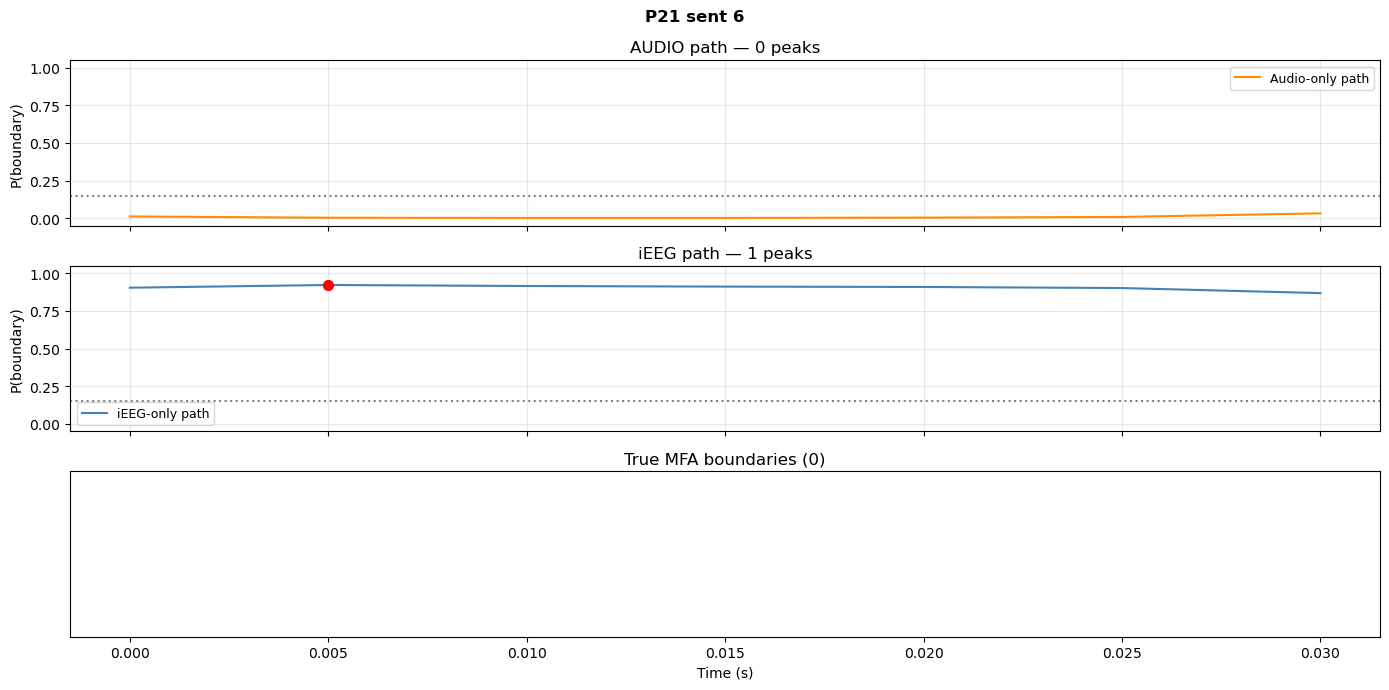

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Visualise predictions on one test sentence (both modalities)
# ═══════════════════════════════════════════════════════════════════════════════

def plot_joint_predictions(model, item, n_seconds=8):
    """Plot model output from both modalities + true boundaries."""
    peaks_e, probs_e = predict_boundaries_ieeg_only(model, item['eeg'], item['pid'])
    peaks_a, probs_a = predict_boundaries_audio_only(model, item['mfcc'], item['pid'])
    n = min(int(n_seconds * FRAME_HZ), len(probs_e), len(probs_a))
    t = np.arange(n) / FRAME_HZ

    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    # Audio path
    axes[0].plot(t, probs_a[:n], lw=1.5, color='darkorange',
                 label='Audio-only path')
    pe_a = [p for p in peaks_a if p < n]
    axes[0].scatter([p/FRAME_HZ for p in pe_a],
                    [probs_a[p] for p in pe_a],
                    color='red', s=50, zorder=10)
    axes[0].axhline(PEAK_HEIGHT, color='gray', ls=':')
    axes[0].set_ylim(-0.05, 1.05); axes[0].set_ylabel('P(boundary)')
    axes[0].set_title(f"AUDIO path — {len(pe_a)} peaks")
    axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

    # iEEG path
    axes[1].plot(t, probs_e[:n], lw=1.5, color='steelblue',
                 label='iEEG-only path')
    pe_e = [p for p in peaks_e if p < n]
    axes[1].scatter([p/FRAME_HZ for p in pe_e],
                    [probs_e[p] for p in pe_e],
                    color='red', s=50, zorder=10)
    axes[1].axhline(PEAK_HEIGHT, color='gray', ls=':')
    axes[1].set_ylim(-0.05, 1.05); axes[1].set_ylabel('P(boundary)')
    axes[1].set_title(f"iEEG path — {len(pe_e)} peaks")
    axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

    # True boundaries
    true_in_window = [tb for tb in item['boundary_times'] if tb * FRAME_HZ < n]
    for tb in true_in_window:
        axes[2].axvline(tb, color='green', alpha=0.5, lw=1)
    axes[2].set_ylim(0, 1); axes[2].set_yticks([])
    axes[2].set_xlabel('Time (s)')
    axes[2].set_title(f"True MFA boundaries ({len(true_in_window)})")

    plt.suptitle(f"{item['pid']} sent {item['sentence_idx']}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


if 'model' in dir() and 'test_ds' in dir() and test_ds:
    plot_joint_predictions(model, test_ds[0], n_seconds=8)

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 13 — Save model
# ═══════════════════════════════════════════════════════════════════════════════

if 'model' in dir():
    out_path = f'boundary_detector_joint_{datetime.now().strftime("%Y%m%d_%H%M")}.pt'
    torch.save({
        'model_state':         model.state_dict(),
        'per_patient_eeg_n_ch': {pid: model.eeg_proj[pid].in_features
                                  for pid in model.eeg_proj},
        'mfcc_dim':            model.mfcc_proj.in_features,
        'config': {
            'hidden_dim':     HIDDEN_DIM,
            'n_lstm_layers':  N_LSTM_LAYERS,
            'dropout':        DROPOUT,
            'frame_hz':       FRAME_HZ,
            'n_mfcc':         N_MFCC,
            'n_mels':         N_MELS,
            'pos_weight':     POS_WEIGHT,
            'mod_dropout':    MOD_DROPOUT,
        },
    }, out_path)
    print(f"\n  Saved trained joint detector to {out_path}")